# Customer Churn Analysis in a Telecommunications Company
## Table of Contents

1. Business Understanding
2. Dataset Understanding
3. Data Cleaning
4. Descriptive Analysis
5. Segment Analysis
6. Multi-Variable Analysis
7. Revenue Impact Analysis
8. High-Risk Customer Segments
9. Business Recommendations
10. Executive Summary

## Business Understanding

This dataset contains customer information from a telecommunications company offering phone, internet, and value-added services.

The objective of the analysis is to understand customer churn behavior and identify the factors associated with customer attrition.

Customer churn occurs when a customer discontinues the company's services. Reducing churn is important because retaining existing customers is generally less costly than acquiring new customers.

This project aims to identify high-risk customer segments and provide actionable business recommendations to improve customer retention.
## Dataset Overview
The dataset contains 7,043 customer records and 21 variables describing customer demographics, account information, subscribed services, billing characteristics, and churn status.

Target Variable:
- Churn (Yes / No)

Key Feature Categories:
- Customer Demographics
- Account Information
- Internet Services
- Value-Added Services
- Billing & Payment Information
## Project Objectives
The primary objectives of this analysis are:

1. Measure the overall churn rate.
2. Identify customer segments with higher churn risk.
3. Analyze the impact of contracts, services, billing, and pricing on churn.
4. Understand customer lifecycle patterns.
5. Develop actionable recommendations to improve customer retention.

# 1. Dataset Understanding

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
#df = pd.read_csv(r"D:\churn\Telco_Customer_Churn.csv")
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape 

(7043, 21)

### Insight

The dataset contains information for 7,043 telecom customers across 21 variables.

This provides a sufficiently large sample to analyze customer churn patterns and identify meaningful business trends.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Structure Observations

- The dataset contains 7,043 customer records and 21 columns.
- Most variables are categorical and stored as object data types.
- Three variables are numerical:
  - SeniorCitizen (integer)
  - tenure (integer)
  - MonthlyCharges (float)
- The TotalCharges column is currently stored as an object data type, although it appears to represent monetary values.
- This suggests a potential data quality issue that requires further investigation before analysis.
- No missing values were detected using `isnull()`.
- No duplicate records were detected using `duplicated()`.
- Further data quality checks will be performed to identify hidden missing values or formatting issues.

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [8]:
df['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [9]:
(df['TotalCharges']== ' ').sum()

11

### Data Quality Finding

Although the dataset initially showed no missing values using `isnull()`, further investigation revealed that the `TotalCharges` column contained 11 blank string values.

These blank spaces prevented the column from being recognized as a numeric variable and caused it to be stored as an object data type.

This highlights the importance of checking for hidden missing values in addition to standard null value checks.

In [10]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
#fill the emplty space with nan
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [12]:
#changing the data type form object ot numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [13]:
df['TotalCharges'].isnull().sum()

11

### Data Quality Investigation Result

Further investigation revealed that all 11 missing TotalCharges values belonged to customers with a tenure of 0 months.

This suggests that these customers had recently joined the telecom service and had not yet accumulated any total charges.

Therefore, the missing values appear to have a valid business explanation rather than being caused by data collection errors.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Type Correction

The `TotalCharges` column was originally stored as an object data type due to the presence of blank string values.

The blank strings were replaced with missing values (`NaN`) and the column was converted to a numeric data type (`float64`).

After conversion, 11 missing values were identified in the `TotalCharges` column.

In [15]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


### Missing Values Investigation

The `TotalCharges` column contained 11 missing values.

After investigating these records, it was found that all affected customers had a tenure of 0 months.

This indicates that the customers had recently joined the service and had not yet accumulated any total charges.

Therefore, the missing values have a valid business explanation.

In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [17]:
df['TotalCharges'].isnull().sum()

0

## Data Cleaning Summary

The dataset was assessed for missing values, duplicate records, and incorrect data types.

### Findings

- No duplicate records were found.
- No standard null values were detected initially.
- The `TotalCharges` column was stored as an object data type due to hidden blank string values.
- 11 hidden missing values were identified in `TotalCharges`.
- All affected customers had a tenure of 0 months, indicating newly acquired customers who had not yet accumulated any charges.

### Actions Taken

- Replaced blank strings with missing values (`NaN`).
- Converted `TotalCharges` from object to float64.
- Filled the 11 missing values with 0 based on business logic.

### Result

The dataset is now clean and ready for exploratory data analysis.

# 3.1 Level 1 — Descriptive Analysis

## Business Question 1

### What is the overall churn rate?

Business Objective:

Understand the magnitude of customer churn and determine whether customer retention is a significant business problem.

In [18]:
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [19]:
df['Churn'].value_counts(normalize=True)*100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

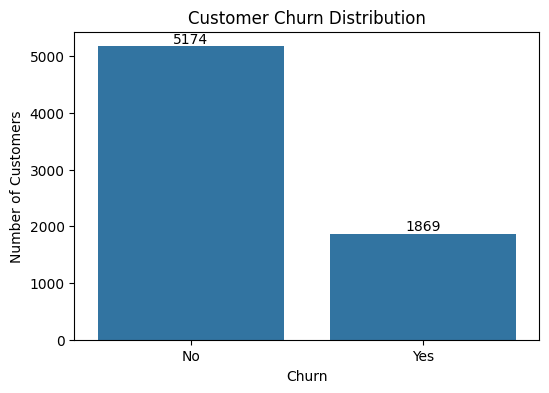

In [20]:
#Countplot for the churn 
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df)
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## Business Question 1: What is the Overall Churn Rate?

### Business Objective

Measure the proportion of customers who have left the company and evaluate the overall severity of customer churn.

### Findings

Out of 7,043 customers:

- 5,174 customers remained with the company.
- 1,869 customers churned.

The overall churn rate is **26.54%**.

### Insight

Approximately one out of every four customers has left the company.

A churn rate of 26.54% indicates a significant customer retention challenge and highlights the need to identify the factors driving customer attrition.

## Business Question 2: What is the Customer Tenure Distribution?

### Business Objective

Understand how long customers have remained with the company and identify whether the customer base consists primarily of new, mid-term, or long-term customers.

In [21]:
#Summary statistics of tenure
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

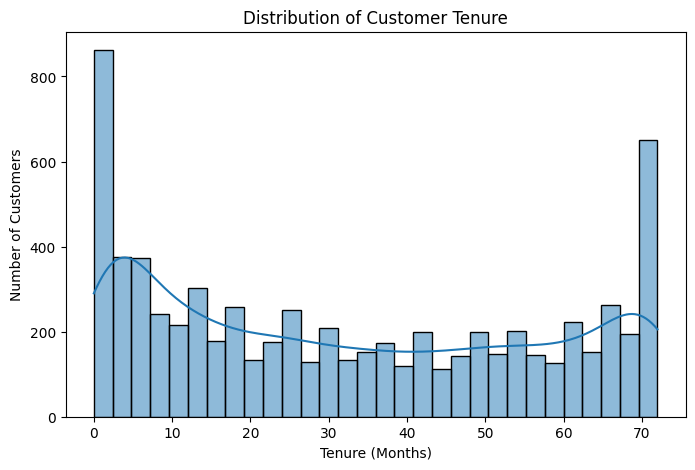

In [22]:
#Create tenure distribution plot
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Insight

Customer tenure ranges from 0 to 72 months, with an average tenure of approximately 32 months.

The tenure distribution shows two noticeable peaks:

- A large concentration of newly acquired customers with very low tenure.
- A large concentration of long-term customers with tenure close to 72 months.

This indicates that the company has successfully retained a substantial group of loyal customers while also continuously acquiring new customers.

The relatively lower concentration of customers in the middle tenure range suggests that customer retention behavior may differ significantly between new and long-term customers.

Further analysis is required to determine whether churn is concentrated among newer customers or long-term customers.

## Business Question 3: What is the Distribution of Monthly Charges Across Customers?

### Business Objective

Understand how monthly charges are distributed across the customer base and identify whether customers are concentrated in low, medium, or high monthly charge segments.

This analysis helps us understand the company's pricing landscape before investigating whether monthly charges influence customer churn.

In [23]:
#Summary statistics of monthly charges
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

### Findings

- Monthly charges range from 18.25 to 118.75.
- The average monthly charge is approximately 64.76.
- The median monthly charge is 70.35.
- 25% of customers pay less than 35.50 per month.
- 25% of customers pay more than 89.85 per month.

### Initial Observation

The company serves customers across a wide range of pricing plans, from low-cost subscriptions to premium service packages.

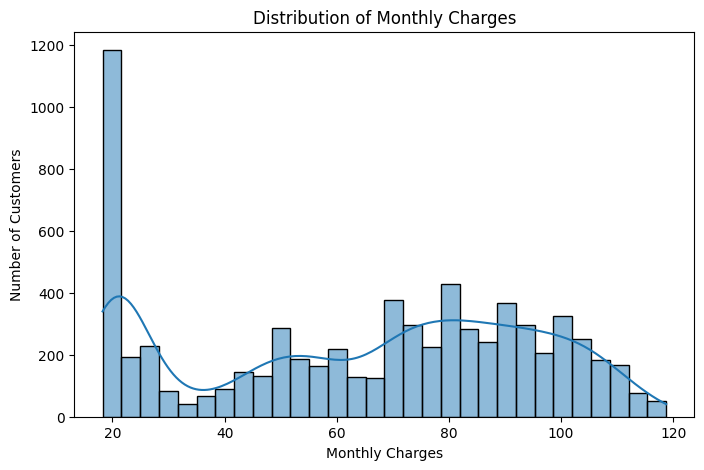

In [24]:
#Create monthly charges distribution plot
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

### Insight

Monthly charges range from 18.25 to 118.75, indicating substantial variation in customer subscription costs.

The distribution is not uniform and shows multiple peaks, suggesting that customers are grouped into different pricing tiers or service packages.

A large concentration of customers exists in the low-charge range (around 20–25), while another significant group pays between 70 and 100 per month.

This indicates that the telecom company serves multiple customer segments with different service levels and pricing structures.

Further analysis is required to determine whether customers with higher monthly charges are more likely to churn.

## Business Question 4: What is the Distribution of Total Charges Across Customers?

### Business Objective

Understand how much total revenue has been generated from customers over their lifetime with the company.

This analysis helps identify whether the customer base is dominated by low-value or high-value customers and provides context for future churn impact analysis.

In [25]:
#Summary statistics fo total charges
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

### Findings

- Total charges range from 0 to 8684.80.
- The average total charge is approximately 2279.73.
- The median total charge is 1394.55.
- 25% of customers have generated less than 398.55 in total revenue.
- 25% of customers have generated more than 3786.60 in total revenue.

### Initial Observation

The large difference between the mean and median suggests that a portion of customers have generated significantly higher revenue than the typical customer.

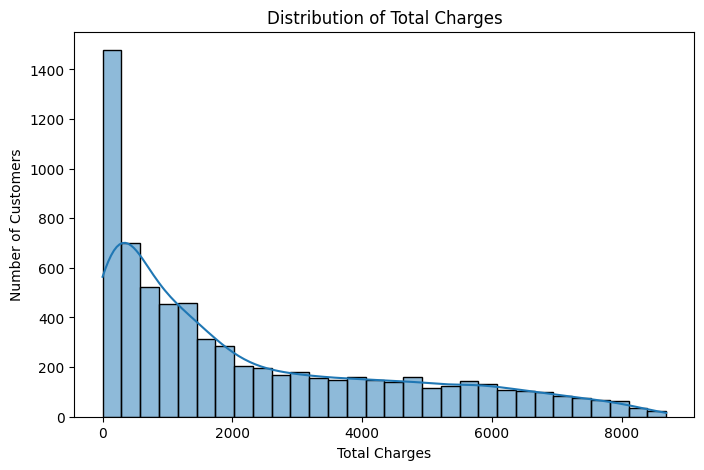

In [26]:
#Create total charges distribution plot
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

### Insight

Total charges exhibit a strongly right-skewed distribution.

Most customers have accumulated relatively low total charges, while a smaller group of long-term customers has generated substantially higher lifetime revenue.

The large gap between the mean (2279.73) and median (1394.55) further confirms the presence of high-value customers that pull the average upward.

This suggests that a relatively small segment of customers contributes a significant portion of the company's lifetime revenue, making customer retention particularly important for these high-value customers.

## Business Question 5: How Are Customers Split Across Contract Types?

### Business Objective

Understand how customers are distributed across different contract types and identify which plans are most commonly chosen.

Contract type is an important variable because it often influences customer loyalty and retention behavior.

In [27]:
#Count customers by contract type
df['Contract'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

### Findings

- 3,875 customers are on Month-to-Month contracts.
- 1,473 customers are on One-Year contracts.
- 1,695 customers are on Two-Year contracts.

### Initial Observation

Month-to-Month contracts represent the largest customer segment, accounting for more than half of all customers.

This indicates that a large portion of the customer base prefers short-term flexibility over long-term commitments.

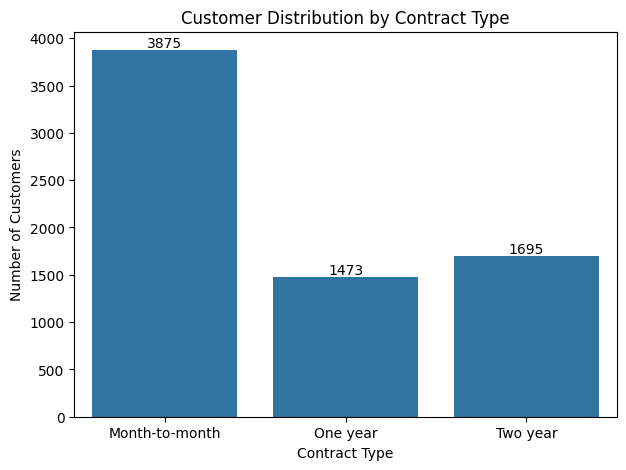

In [28]:
#Visualization customer distribution by contract type
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Contract', data = df)
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Insight

Month-to-Month contracts are the most popular contract type, with 3,875 customers, representing more than half of the customer base.

In comparison, One-Year and Two-Year contracts have significantly fewer customers, with 1,473 and 1,695 customers respectively.

This indicates that most customers prefer flexible short-term contracts rather than long-term commitments.

Since contract type often influences customer loyalty and retention, it is expected to be an important factor in explaining customer churn. This relationship will be investigated in later analysis.

# 3.2 Level 2 — Segment Analysis

## Business Question 6: Does Gender Affect Customer Churn?

### Business Objective

Determine whether customer churn differs between male and female customers.

Understanding whether gender is associated with churn can help identify demographic patterns in customer retention.

In [29]:
#Count customers by gender
df['gender'].value_counts()

Male      3555
Female    3488
Name: gender, dtype: int64

In [30]:
#Calculate churn by gender
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


### Findings

- The customer base is almost evenly split between male and female customers.
- Female customers account for 3,488 records.
- Male customers account for 3,555 records.
- The raw churn counts appear very similar between genders.

### Initial Observation

Based on customer counts alone, there does not appear to be a large difference in churn behavior between male and female customers.

However, churn rates should be calculated before drawing conclusions.

In [31]:
#Calculate churn rate by gender
pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
)* 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


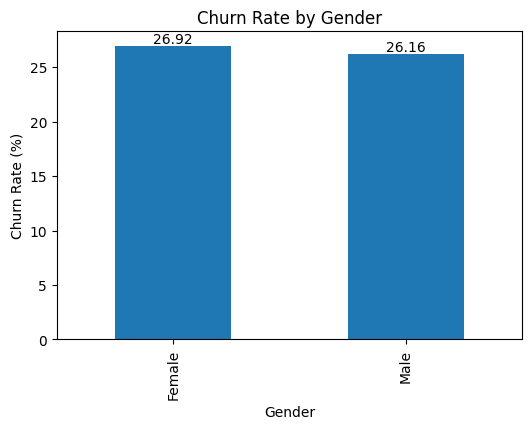

In [32]:
#Calculate churn rate by gender
gender_churn = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100
#plot churn rate by gender 
ax = gender_churn['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)
#Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.show()    

### Insight

The churn rate is very similar across genders.

- Female churn rate: 26.92%
- Male churn rate: 26.16%

The difference between the two groups is less than 1 percentage point, indicating that gender has little influence on customer churn behavior.

This suggests that other factors such as contract type, tenure, pricing, and subscribed services are likely to play a much larger role in explaining customer churn.

## Business Question 7: Are Senior Citizens More Likely to Churn Than Younger Customers?

### Business Objective

Determine whether senior citizens exhibit different churn behavior compared to non-senior customers.

Understanding the relationship between age group and churn can help the company design targeted retention strategies for different customer segments.

In [33]:
#Count customers by senior citizen status
df['SeniorCitizen'].value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [34]:
#Churn count by senior citizen status
pd.crosstab(df['SeniorCitizen'],df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


### Findings

- The majority of customers are non-senior citizens.
- Non-senior customers account for 5,901 records.
- Senior citizens account for 1,142 records.
- Churn counts alone suggest that both groups experience customer attrition.

### Initial Observation

Because the number of customers differs significantly between the two groups, churn rates should be calculated before making any conclusions about churn behavior.

In [35]:
#Calculate churn rate by senior citizen status
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'

)*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


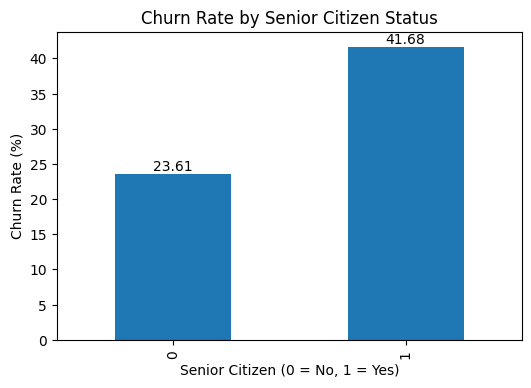

In [36]:
#Calculate churn rate by senior citizen status
senior_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100
#Plot churn rate
ax = senior_churn['Yes'].plot(kind='bar',figsize=(6,4)
)
#Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.show()

### Insight

Senior citizens exhibit a substantially higher churn rate than non-senior customers.

- Non-Senior Citizen Churn Rate: 23.61%
- Senior Citizen Churn Rate: 41.68%

The churn rate among senior citizens is approximately 18 percentage points higher than that of non-senior customers.

This suggests that senior citizens may face different challenges, needs, or service expectations that influence their decision to leave the company.

Senior citizens should be considered a high-risk customer segment and may require targeted retention strategies.

## Business Question 8: Do Customers with Partners or Dependents Churn Less?

### Business Objective

Understand whether family-related factors such as having a partner or dependents influence customer retention behavior.

In [37]:
#Count customers by partner status
df['Partner'].value_counts()

No     3641
Yes    3402
Name: Partner, dtype: int64

In [38]:
#Churn count by partner status
pd.crosstab(df['Partner'], df['Churn'])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


### Findings

- 3,641 customers do not have a partner.
- 3,402 customers have a partner.
- The customer distribution is relatively balanced between the two groups.

### Initial Observation

Customers without partners appear to have a higher number of churned customers compared to customers with partners.

However, churn rates should be calculated before drawing conclusions.

In [39]:
#Calculate churn rate by partner status
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Insight

Partner status appears to have a significant relationship with customer churn.

- Customers without partners have a churn rate of 32.96%.
- Customers with partners have a churn rate of 19.66%.

Customers without partners churn approximately 13 percentage points more frequently than customers with partners.

This suggests that customers with partners may have greater service stability or stronger long-term commitment, making them less likely to leave the company.

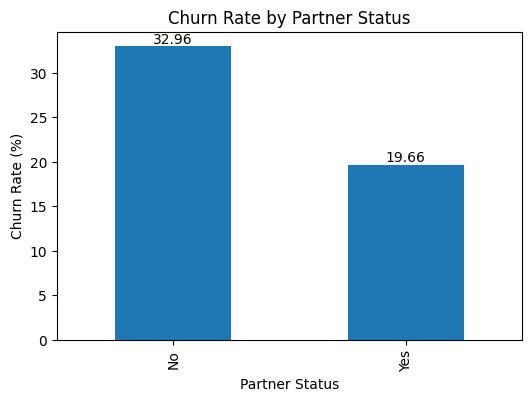

In [40]:
#Calculate churn rate by partner status
partner_churn = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100
#Plot churn rate by partner status
ax = partner_churn['Yes'].plot(
    kind='bar', figsize=(6,4)
)
#Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Churn Rate by Partner Status')
plt.xlabel('Partner Status')
plt.ylabel('Churn Rate (%)')
plt.show()

In [41]:
#Count customers by dependent status
df['Dependents'].value_counts()

No     4933
Yes    2110
Name: Dependents, dtype: int64

In [42]:
#Churn count by dependent status
pd.crosstab(df['Dependents'],df['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


### Findings

- 4,933 customers do not have dependents.
- 2,110 customers have dependents.
- Customers without dependents account for the majority of the customer base.

### Initial Observation

Customers without dependents appear to have a larger number of churned customers.

However, churn rates should be calculated before making conclusions because the group sizes are different.

In [43]:
#Calcuate churn rate by dependent status
pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


### Insight

Dependent status shows a strong relationship with customer churn.

- Customers without dependents have a churn rate of 31.28%.
- Customers with dependents have a churn rate of 15.45%.

Customers without dependents churn at approximately twice the rate of customers with dependents.

This suggests that customers with dependents may have more stable household service requirements and are therefore less likely to switch providers.

Among the family-related variables analyzed so far, dependent status appears to be one of the strongest indicators of customer retention.

## Business Question 9: Which Contract Type Has the Highest Churn Rate?

### Business Objective

Determine whether customer contract type influences churn behavior and identify which contract category presents the highest retention risk.

Contract type is often one of the strongest indicators of customer loyalty and long-term retention.

In [44]:
#Churn count by contract type
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


### Findings

- Month-to-Month customers account for the largest number of churned customers.
- One-Year contract customers show substantially lower churn counts.
- Two-Year contract customers show the lowest churn counts.

### Initial Observation

Contract type appears to have a strong relationship with customer churn.

However, churn rates should be calculated before making conclusions because the number of customers differs across contract categories.

In [45]:
#Calculate churn rate by contract type
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


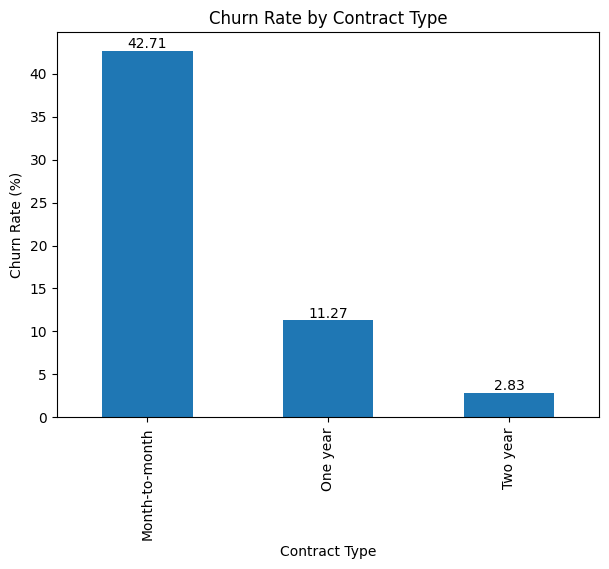

In [46]:
#Calculate churn rate by contract type
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100
#plot churn rate by contract type
ax = contract_churn['Yes'].plot(kind='bar',figsize=(7,5))
#Add data labels 
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

### Insight

Contract type is one of the strongest predictors of customer churn in the dataset.

- Month-to-Month customers have a churn rate of 42.71%.
- One-Year contract customers have a churn rate of 11.27%.
- Two-Year contract customers have a churn rate of only 2.83%.

The results show a clear inverse relationship between contract duration and churn.

Customers on Month-to-Month contracts are significantly more likely to leave the company, while customers on longer-term contracts exhibit substantially higher retention rates.

This suggests that encouraging customers to move from Month-to-Month plans to longer-term contracts could be an effective customer retention strategy.

### Key Business Finding

Contract type appears to be the strongest factor associated with customer churn among the variables analyzed so far.

## Business Question 10: Which Payment Method Is Most Associated With Customer Churn?

### Business Objective

Understand whether customer churn differs across payment methods and identify which payment method is associated with the highest retention risk.

Payment behavior can reveal customer preferences and potential friction points in the billing process.

In [47]:
#Count customers by payment menthod
df['PaymentMethod'].value_counts()

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

In [48]:
#Churn count by paymet method
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


### Findings

- Electronic Check is the most commonly used payment method among customers.
- Electronic Check also has the highest number of churned customers.
- Bank Transfer (Automatic), Credit Card (Automatic), and Mailed Check show substantially lower churn counts.

### Initial Observation

Electronic Check appears to be associated with a higher level of customer churn.

However, churn rates should be calculated before drawing conclusions because customer counts differ across payment methods.

In [49]:
# Calculate churn rate by payment method
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


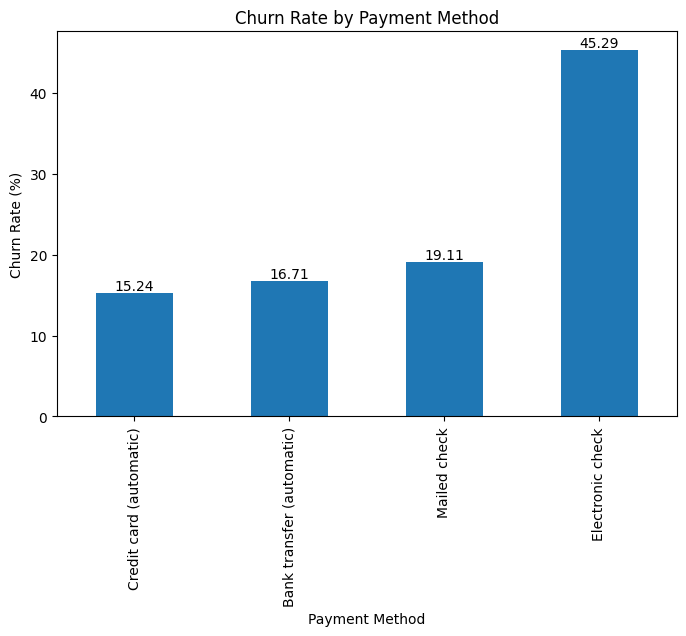

In [50]:
# Calculate churn rate by payment method
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

# Plot churn rate by payment method
ax = payment_churn['Yes'].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.show()

### Insight

Payment method shows a strong relationship with customer churn.

- Electronic Check customers have the highest churn rate at 45.29%.
- Mailed Check customers have a churn rate of 19.11%.
- Bank Transfer (Automatic) customers have a churn rate of 16.71%.
- Credit Card (Automatic) customers have the lowest churn rate at 15.24%.

Electronic Check customers churn at nearly three times the rate of customers using automatic payment methods.

This suggests that customers enrolled in automatic billing exhibit stronger retention behavior, while Electronic Check customers represent a high-risk segment that may require targeted retention efforts.

## Business Question 11: Does Internet Service Type Affect Customer Churn?

### Business Objective

Analyze whether churn behavior differs across internet service types and identify which service category is associated with the highest churn risk.

Understanding this relationship can help the company identify service offerings that may contribute to customer retention or customer attrition.

In [51]:
#Count customers by internet service type
df['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

In [52]:
#Churn count by internet service type
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


### Findings

- Fiber Optic is the most commonly used internet service.
- DSL is the second most common internet service.
- 1,526 customers do not subscribe to internet service.

### Initial Observation

Fiber Optic customers account for the largest number of churned customers.

However, churn rates should be calculated before drawing conclusions because customer counts differ across internet service categories.

In [53]:
#Calculate churn rate by internet service type
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Insight

Internet service type shows a strong relationship with customer churn.

- Fiber Optic customers have the highest churn rate at 41.89%.
- DSL customers have a churn rate of 18.96%.
- Customers without internet service have the lowest churn rate at 7.40%.

Fiber Optic customers churn at more than twice the rate of DSL customers and nearly six times the rate of customers without internet service.

This suggests that Fiber Optic customers represent a high-risk segment and should be investigated further to understand the underlying drivers of churn.

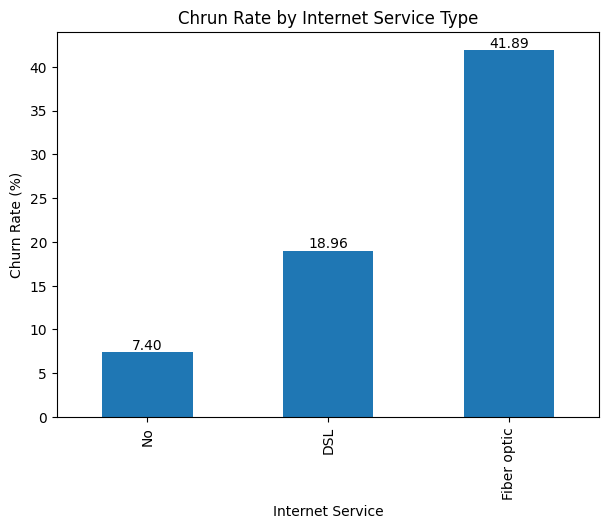

In [54]:
#Calculate churn rate by internet service type
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100
#Plot churn rate by internet service type 
ax = internet_churn['Yes'].sort_values().plot(kind='bar', figsize=(7,5))

#Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Chrun Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.show()

## Business Question 12: Does Paperless Billing Correlate with Customer Churn?

### Business Objective

Determine whether customers who use paperless billing exhibit different churn behavior compared to customers who receive traditional billing.

Understanding this relationship may help identify customer segments that require additional retention efforts.

In [55]:
#Count customers by paperless billing status
df['PaperlessBilling'].value_counts()

Yes    4171
No     2872
Name: PaperlessBilling, dtype: int64

In [56]:
#churn count by paperless billing status
pd.crosstab(
    df['PaperlessBilling'], df['Churn']
)

Churn,No,Yes
PaperlessBilling,,
No,2403,469
Yes,2771,1400


### Findings

- 4,171 customers use paperless billing.
- 2,872 customers do not use paperless billing.
- Customers using paperless billing account for the majority of the customer base.

### Initial Observation

Customers using paperless billing appear to have a substantially higher number of churned customers compared to customers who do not use paperless billing.

However, churn rates should be calculated before drawing conclusions.

In [57]:
#Calculate churn rate by paperless billing status
pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


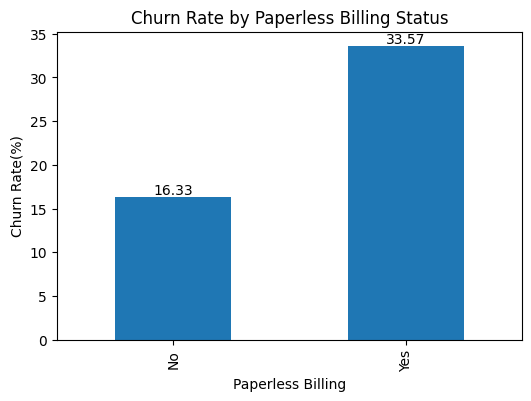

In [58]:
#Calculate churn rate by paperless billing status
paperless_churn = pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100
#plot churn rate by paperless billing status
ax = paperless_churn['Yes'].plot(kind='bar',figsize=(6,4))

#Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Churn Rate by Paperless Billing Status') 
plt.xlabel('Paperless Billing')
plt.ylabel('Churn Rate(%)')
plt.show()   

### Insight

Paperless billing customers exhibit a significantly higher churn rate compared to customers who do not use paperless billing.

- Paperless Billing = Yes → 33.57% churn rate
- Paperless Billing = No → 16.33% churn rate

Customers using paperless billing churn at more than twice the rate of customers receiving traditional billing.

This suggests that paperless billing is strongly associated with customer churn. However, paperless billing itself may not be the direct cause of churn and could be related to other customer characteristics such as contract type, payment method, or internet service usage.

Further analysis is required to understand the underlying factors driving this relationship.

# 3.3 Level 3 — Multi-Variable Analysis

In the previous section, each variable was analyzed individually against churn.

In this section, multiple variables will be examined together to identify deeper patterns and understand the characteristics of high-risk customer segments.

The objective is not only to identify which customers churn, but also to understand why they are more likely to leave the company.

In [59]:
#Compare tenure statistics by churn status
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


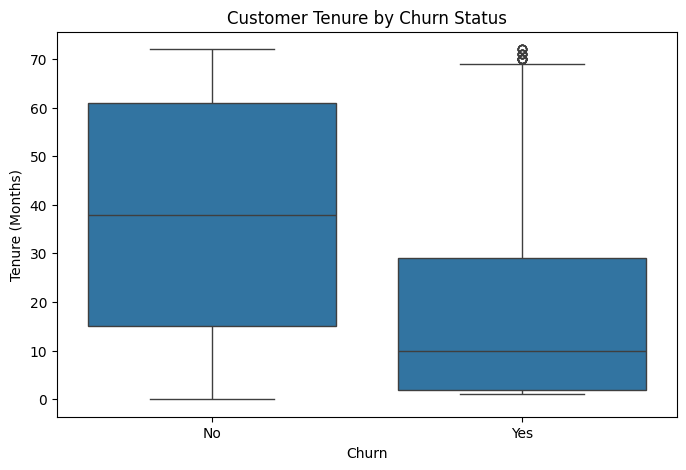

In [60]:
#Compare tenure distribution by churn status
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='tenure', data = df)

plt.title("Customer Tenure by Churn Status")
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### Findings

Customers who churned have substantially lower tenure than customers who remained with the company.

- Average tenure of retained customers: 37.57 months
- Average tenure of churned customers: 17.98 months

The median tenure for churned customers is only 10 months, compared to 38 months for retained customers.

Additionally, 25% of churned customers leave within the first 2 months of joining the company.

### Initial Observation

Customer churn appears to be concentrated among newer customers, while long-term customers exhibit significantly higher retention.

This suggests that the early stages of the customer lifecycle may be the most critical period for customer retention efforts.

In [61]:
#Create tenure group
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins =[0,12,24,48,72],
    labels=['0-12 Months','13-24 Months','25-48 Months','49-72 Months'],
    include_lowest=True
)
#Count customers in each tenure group
df['TenureGroup'].value_counts().sort_index()

0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: TenureGroup, dtype: int64

### Tenure Group Distribution

Customers were grouped into four tenure categories to better understand customer lifecycle stages.

- 0–12 Months: 2,186 customers
- 13–24 Months: 1,024 customers
- 25–48 Months: 1,594 customers
- 49–72 Months: 2,239 customers

### Initial Observation

The customer base contains both a substantial number of newly acquired customers and a large number of long-term customers.

This suggests that the company is successfully acquiring new customers while also retaining a significant portion of customers over multiple years.

In [62]:
#Calculate churn rate by tenure group
pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TenureGroup,,
0-12 Months,52.561757,47.438243
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


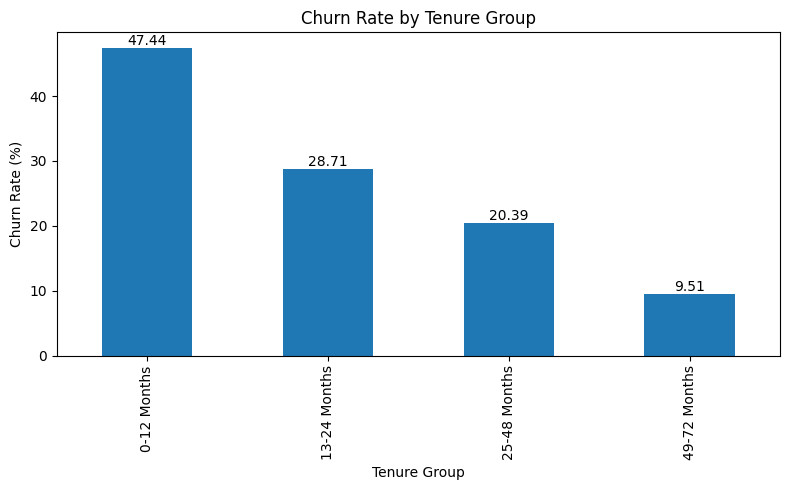

In [63]:
#Calculate churn rate by tenure group
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
)* 100

#plot churn rate by tenure group 
ax = tenure_churn['Yes'].plot(kind='bar',figsize=(8,5))

#Add data labels
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f')
    
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()    
plt.show()

### Insight

Customer tenure exhibits one of the strongest relationships with churn in the dataset.

- Customers in the first 12 months have a churn rate of 47.44%.
- Customers with 13–24 months tenure have a churn rate of 28.71%.
- Customers with 25–48 months tenure have a churn rate of 20.39%.
- Customers with 49–72 months tenure have a churn rate of only 9.51%.

The results reveal a clear pattern: churn decreases consistently as customer tenure increases.

Nearly half of all customers leave within their first year, while long-term customers demonstrate significantly stronger loyalty and retention.

This suggests that the first year of the customer lifecycle is the most critical period for retention efforts and should be prioritized by the business.

## Business Question 14: Do Customers with Higher Monthly Charges Churn More Frequently?

### Business Objective

Determine whether monthly charges influence customer churn behavior.

Understanding the relationship between pricing and churn can help identify whether customers are sensitive to higher service costs and whether pricing strategies contribute to customer attrition.

In [64]:
#Compare monthly charges by churn status
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Findings

Customers who churned have noticeably higher monthly charges than customers who remained with the company.

- Average Monthly Charges (Retained Customers): 61.27
- Average Monthly Charges (Churned Customers): 74.44

The median monthly charge for churned customers is 79.65 compared to 64.43 for retained customers.

### Initial Observation

Customers who leave the company tend to pay higher monthly charges than customers who remain.

This suggests that pricing may be associated with customer churn and should be investigated further through visual analysis.

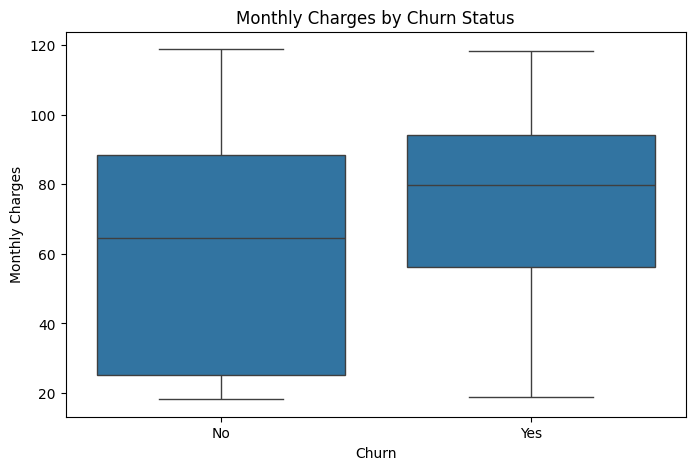

In [65]:
#Compare monthly charges by churn status
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data = df
)
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

### Insight

Monthly charges show a meaningful relationship with customer churn.

Customers who churned have noticeably higher monthly charges than customers who remained with the company.

- Average Monthly Charges (Retained Customers): 61.27
- Average Monthly Charges (Churned Customers): 74.44

The boxplot further confirms that churned customers tend to be concentrated in higher monthly charge ranges.

This suggests that customers paying higher monthly fees may be more sensitive to pricing, perceived value, or competing offers in the market.

The company should further investigate whether pricing strategies or premium service packages contribute to customer attrition.

## Business Question 15: Which Value-Added Services Are Associated With Lower Customer Churn?

### Business Objective

Determine whether additional services such as Online Security, Online Backup, Device Protection, and Tech Support influence customer retention.

Understanding the impact of these services can help identify which offerings provide the greatest retention benefits.

In [66]:
#churn count by online security status
pd.crosstab(df['OnlineSecurity'], df['Churn'])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


### Findings

- Customers without Online Security account for the highest number of churned customers.
- Customers with Online Security show substantially lower churn counts.
- Customers without internet service exhibit the lowest churn counts.

### Initial Observation

Online Security appears to be associated with customer retention. However, churn rates should be calculated before drawing conclusions because the group sizes differ.

In [67]:
#Calculate churn rate by online security status
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### Insight

Online Security shows a strong relationship with customer churn.

- Customers without Online Security have a churn rate of 41.77%.
- Customers with Online Security have a churn rate of 14.61%.

Customers without Online Security churn nearly three times more frequently than customers who subscribe to the service.

This suggests that Online Security may provide additional value that increases customer retention and reduces the likelihood of switching providers.

In [68]:
#Churn count by tech support status
pd.crosstab(df['TechSupport'],df['Churn'])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [69]:
#Calculate churn rate by tech support status
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Insight

Tech Support shows a strong relationship with customer churn.

- Customers without Tech Support have a churn rate of 41.64%.
- Customers with Tech Support have a churn rate of 15.17%.

Customers without Tech Support churn nearly three times more frequently than customers who subscribe to the service.

This suggests that access to technical assistance may improve customer satisfaction and increase customer retention.

In [70]:
#Churn count by online backup status
pd.crosstab(df['OnlineBackup'],df['Churn'])

Churn,No,Yes
OnlineBackup,,
No,1855,1233
No internet service,1413,113
Yes,1906,523


In [71]:
# Calculate churn rate by online backup status
pd.crosstab(
    df['OnlineBackup'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


### Insight

Online Backup is associated with lower customer churn.

- Customers without Online Backup have a churn rate of 39.93%.
- Customers with Online Backup have a churn rate of 21.53%.

Customers who subscribe to Online Backup are substantially less likely to churn than customers who do not.

However, the retention effect appears weaker than the impact observed for Online Security and Tech Support.

In [72]:
#Churn count by device protection status
pd.crosstab(df['DeviceProtection'], df['Churn'])

Churn,No,Yes
DeviceProtection,,
No,1884,1211
No internet service,1413,113
Yes,1877,545


In [73]:
# Calculate churn rate by device protection status
pd.crosstab(
    df['DeviceProtection'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


### Insight

Device Protection is associated with lower customer churn.

- Customers without Device Protection have a churn rate of 39.13%.
- Customers with Device Protection have a churn rate of 22.50%.

Customers subscribing to Device Protection are less likely to churn than customers who do not subscribe to the service.

However, the retention effect is weaker than that observed for Online Security and Tech Support.

In [74]:
# Create service comparison table
service_comparison = pd.DataFrame({
    'Service': ['Online Security', 'Tech Support', 'Online Backup', 'Device Protection'],
    'Churn Without Service (%)': [41.77, 41.64, 39.93, 39.13],
    'Churn With Service (%)': [14.61, 15.17, 21.53, 22.50]
})

# Calculate difference
service_comparison['Difference (%)'] = (
    service_comparison['Churn Without Service (%)']
    - service_comparison['Churn With Service (%)']
)

service_comparison.sort_values(
    by='Difference (%)',
    ascending=False
)

,Service,Churn Without Service (%),Churn With Service (%),Difference (%)
0,Online Security,41.77,14.61,27.16
1,Tech Support,41.64,15.17,26.47
2,Online Backup,39.93,21.53,18.40
3,Device Protection,39.13,22.50,16.63


### Overall Insight

All four value-added services are associated with lower customer churn.

Among the services analyzed:

1. Online Security shows the strongest relationship with customer retention.
2. Tech Support shows the second strongest relationship with customer retention.
3. Online Backup provides a moderate retention benefit.
4. Device Protection provides the weakest retention benefit among the four services analyzed.

Customers who subscribe to Online Security or Tech Support exhibit substantially lower churn rates than customers who do not use these services.

These findings suggest that service adoption may play an important role in customer retention and that promoting high-value support and security services could help reduce customer churn.

## Business Question 16: What Does a High-Risk Customer Profile Look Like?

### Business Objective

Identify combinations of customer characteristics that are associated with the highest churn risk.

Rather than analyzing variables independently, this analysis seeks to understand which groups of customers exhibit multiple high-risk behaviors simultaneously.

The goal is to build a profile of customers who are most likely to leave the company and identify opportunities for targeted retention strategies.

In [75]:
#Churn count by contract type and internet service
pd.crosstab([
    df['Contract'], df['InternetService']],
    df['Churn']
)

Churn                            No   Yes
Contract       InternetService           
Month-to-month DSL              829   394
               Fiber optic      966  1162
               No               425    99
One year       DSL              517    53
               Fiber optic      435   104
               No               355     9
Two year       DSL              616    12
               Fiber optic      398    31
               No               633     5

### Findings

Contract type and internet service were analyzed together to understand how combinations of customer characteristics influence churn behavior.

Several combinations show notable differences in churn counts.

In particular, customers with Month-to-Month contracts and Fiber Optic internet service account for a large proportion of churned customers.

### Initial Observation

The interaction between contract type and internet service may provide stronger insights than analyzing either variable individually.

Churn rates are required to identify which customer segments exhibit the highest retention risk.

In [76]:
#Churn rate by Contract and Internet Service
pd.crosstab(
    [df['Contract'], df['InternetService']],
    df['Churn'],
    normalize='index'
)*100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

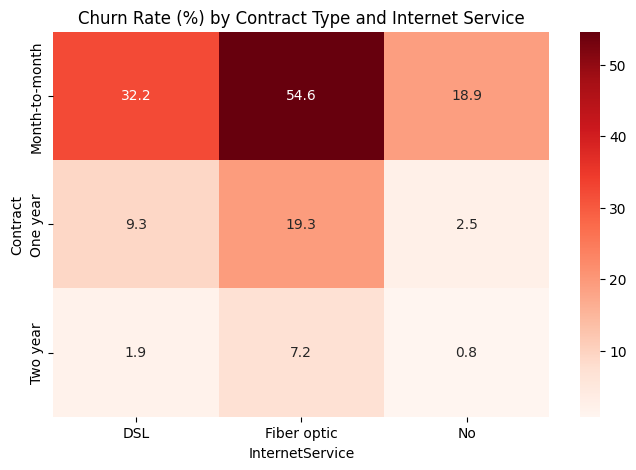

In [77]:
#Churn rate heatmap by contract and internet service
churn_heatmap = pd.crosstab(
    [df['Contract']],df['InternetService'],
    values=(df['Churn'] =='Yes'),
    aggfunc='mean'
) * 100
plt.figure(figsize=(8,5))

sns.heatmap(
    churn_heatmap,
    annot = True,
    fmt='.1f',
    cmap = 'Reds'
)
plt.title('Churn Rate (%) by Contract Type and Internet Service')
plt.show()

### Insight

The combination of Contract Type and Internet Service reveals substantial differences in customer churn behavior.

The highest-risk segment is:

- Month-to-Month Contract + Fiber Optic Internet
- Churn Rate: 54.61%

More than half of customers in this segment leave the company.

The lowest-risk segment is:

- Two-Year Contract + No Internet Service
- Churn Rate: 0.78%

These findings indicate that customer churn is influenced not only by individual factors but also by the interaction between multiple customer characteristics.

Month-to-Month customers using Fiber Optic internet represent one of the most critical customer segments for retention initiatives.

## Business Question 17: How Much Revenue Is Potentially Being Lost Due to Customer Churn?

### Business Objective

Estimate the financial impact of customer churn by comparing revenue generated by churned and retained customers.

Understanding the revenue associated with churn helps quantify the business impact of customer attrition and supports retention-focused decision making.

In [78]:
#Compare total charges by churn status
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


### Findings

Customers who remain with the company generate substantially higher total revenue than customers who churn.

- Average Total Charges (Retained Customers): 2549.91
- Average Total Charges (Churned Customers): 1531.80

The median total charge for retained customers is 1679.53 compared to 703.55 for churned customers.

### Initial Observation

Customers who churn tend to leave before generating significant lifetime revenue.

This suggests that customer churn may reduce future revenue potential by preventing customers from progressing into higher-value long-term relationships.

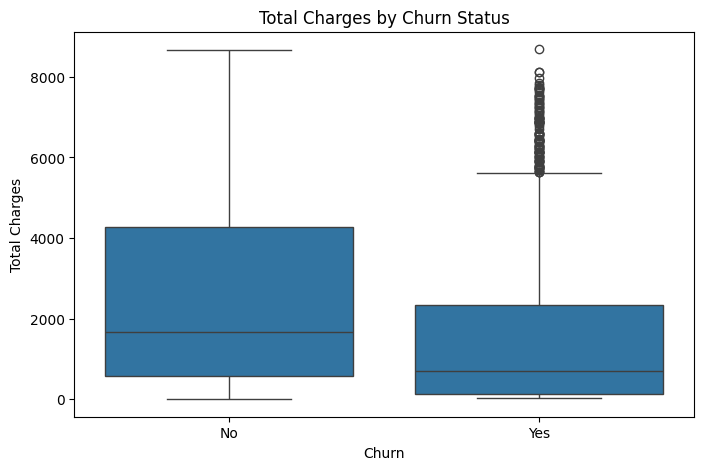

In [79]:
# Compare total charges by churn status
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.title('Total Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

### Insight

Total Charges show a strong relationship with customer churn.

Customers who remain with the company generate substantially higher lifetime revenue than customers who churn.

The boxplot confirms that retained customers accumulate significantly greater total charges, reflecting longer customer relationships and higher lifetime value.

Although most churned customers leave before generating substantial revenue, a small number of high-value customers also churn, representing a potentially significant financial loss to the business.

These findings highlight the importance of retaining customers early in their lifecycle and identifying valuable customers before they leave.

In [80]:
#Calculate total revenue by churn status
df.groupby('Churn')['TotalCharges'].sum()

Churn
No     13193241.8
Yes     2862926.9
Name: TotalCharges, dtype: float64

In [81]:
#Percentage of revenue by churn status
(
    df.groupby('Churn')['TotalCharges'].sum()
    / df['TotalCharges'].sum()
)*100

Churn
No     82.169302
Yes    17.830698
Name: TotalCharges, dtype: float64

### Revenue Impact Analysis

Revenue analysis shows a meaningful financial impact associated with customer churn.

- Revenue generated by retained customers: 13,193,241.8
- Revenue generated by churned customers: 2,862,926.9

Retained customers account for 82.17% of total revenue, while churned customers account for 17.83%.

Although churned customers have generated less historical revenue on average, customer attrition represents a significant business concern because it reduces future revenue opportunities and customer lifetime value.

The findings suggest that improving customer retention, particularly during the early stages of the customer lifecycle, could have a meaningful long-term financial impact on the business.

## Business Question 18: Which Customer Segments Represent the Highest Churn Risk?

### Business Objective

Consolidate findings from previous analyses to identify the customer segments that consistently exhibit the highest churn rates.

The objective is to prioritize customer groups for retention initiatives based on observed churn behavior.

In [82]:
#Create high-risk customer segment ranking table
risk_segments = pd.DataFrame({
    'Segment':[
        'Month-to-Month + Fiber Optic',
        '0-12 Months Tenure',
        'Electronic Check',
        'Month-to-Month Contract',
        'Fiber Optic Internet',
        'No Online Securit',
        'No Tech Support',
        'Senior Citizen',
        'No Partner',
        'No Dependents'
    ],
    
    'Churn Rate (%)':[
        54.61,
        47.44,
        45.29,
        42.71,
        41.89,
        41.77,
        41.64,
        41.68,
        32.96,
        31.28
        
    ]
})
risk_segments = risk_segments.sort_values(
    by='Churn Rate (%)',
    ascending = False
)
risk_segments

,Segment,Churn Rate (%)
0,Month-to-Month + Fiber Optic,54.61
1,0-12 Months Tenure,47.44
2,Electronic Check,45.29
3,Month-to-Month Contract,42.71
4,Fiber Optic Internet,41.89
5,No Online Securit,41.77
7,Senior Citizen,41.68
6,No Tech Support,41.64
8,No Partner,32.96
9,No Dependents,31.28


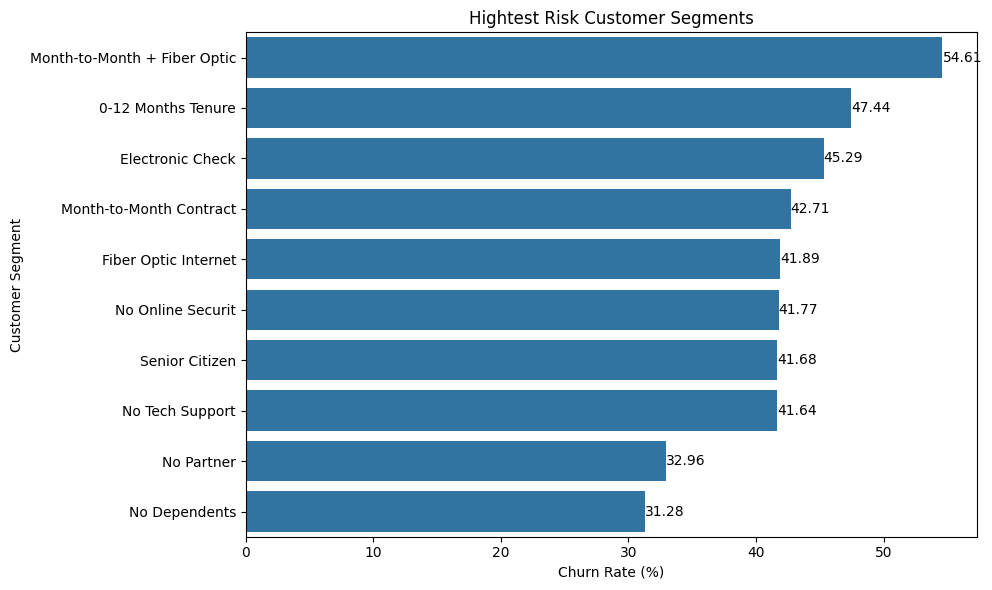

In [83]:
#Visualize highest-risk customer segments
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data = risk_segments,
    x ='Churn Rate (%)',
    y='Segment'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Hightest Risk Customer Segments')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

### Insight

The analysis reveals several customer segments with substantially elevated churn risk.

The highest-risk segment identified is:

- Month-to-Month Contract + Fiber Optic Internet
- Churn Rate: 54.61%

Additional high-risk segments include:

- Customers within their first 12 months
- Customers using Electronic Check payments
- Customers without Online Security
- Customers without Tech Support
- Senior Citizens

These findings indicate that customer churn is not driven by a single factor. Instead, churn is concentrated among customers exhibiting multiple high-risk characteristics simultaneously.

Retention initiatives should prioritize these segments to maximize business impact.

## Churn Driver Ranking Matrix

The following table summarizes the strongest factors associated with customer churn identified throughout the analysis.

In [84]:
# Churn Driver Ranking Matrix

churn_drivers = pd.DataFrame({
    'Factor': [
        'Month-to-Month + Fiber Optic',
        '0-12 Months Tenure',
        'Electronic Check',
        'Month-to-Month Contract',
        'Fiber Optic Internet',
        'No Online Security',
        'Senior Citizen',
        'No Tech Support',
        'No Partner',
        'No Dependents'
    ],

    'Churn Rate (%)': [
        54.61,
        47.44,
        45.29,
        42.71,
        41.89,
        41.77,
        41.68,
        41.64,
        32.96,
        31.28
    ],

    'Risk Level': [
        'Very High',
        'Very High',
        'High',
        'High',
        'High',
        'High',
        'High',
        'High',
        'Moderate',
        'Moderate'
    ]
})

churn_drivers

,Factor,Churn Rate (%),Risk Level
0,Month-to-Month + Fiber Optic,54.61,Very High
1,0-12 Months Tenure,47.44,Very High
2,Electronic Check,45.29,High
3,Month-to-Month Contract,42.71,High
4,Fiber Optic Internet,41.89,High
5,No Online Security,41.77,High
6,Senior Citizen,41.68,High
7,No Tech Support,41.64,High
8,No Partner,32.96,Moderate
9,No Dependents,31.28,Moderate


## Top 5 Business Findings

### 1. New Customers Are Most Likely To Churn

Customers within their first 12 months exhibit a churn rate of 47.44%.

### 2. Month-to-Month Contracts Drive Churn

Month-to-Month customers churn at 42.71%, substantially higher than long-term contract customers.

### 3. Fiber Optic Customers Represent A High-Risk Segment

Fiber Optic customers exhibit a churn rate of 41.89%.

### 4. Online Security And Tech Support Improve Retention

Customers using these services exhibit significantly lower churn rates.

### 5. Electronic Check Customers Churn More Frequently

Electronic Check users have the highest churn rate among payment methods.

## High-Risk Customer Persona

Based on the analysis, the typical high-risk customer profile can be described as:

- Month-to-Month Contract
- Fiber Optic Internet Service
- Electronic Check Payment Method
- No Online Security
- No Tech Support
- Less Than 12 Months Tenure
- Senior Citizen

Customers exhibiting multiple characteristics from this profile are significantly more likely to churn and should be prioritized for retention initiatives.

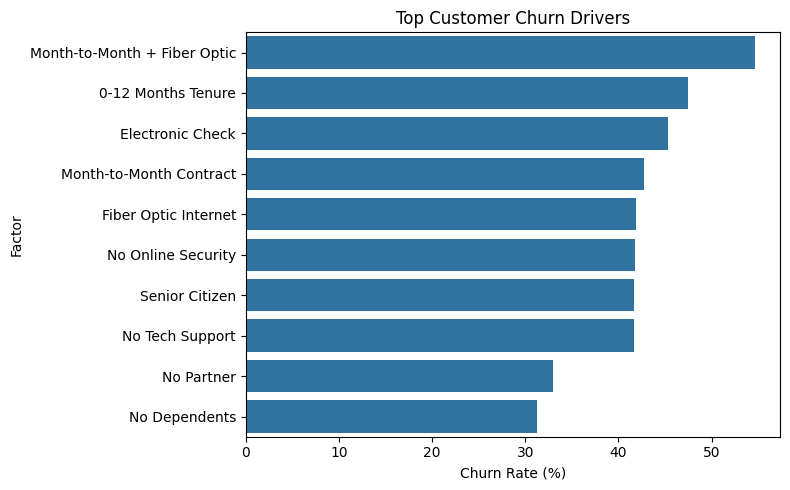

In [86]:
# Top churn drivers visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=churn_drivers.sort_values(
        by='Churn Rate (%)',
        ascending=False
    ),
    x='Churn Rate (%)',
    y='Factor'
)

plt.title('Top Customer Churn Drivers')
plt.tight_layout()
plt.show()

## Business Question 19: What Recommendations Can Help Reduce Customer Churn?

### Business Objective

Based on the findings from the analysis, identify actionable business recommendations that can help improve customer retention and reduce churn.

The recommendations should focus on high-risk customer segments and factors that exhibit strong associations with churn.

### Recommendation 1: Encourage Customers to Move to Long-Term Contracts

Month-to-Month customers exhibit the highest churn rates in the dataset.

The company should encourage customers to transition to One-Year or Two-Year contracts through discounts, loyalty rewards, or bundled service offers.

---

### Recommendation 2: Focus Retention Efforts on New Customers

Customers within their first 12 months show the highest churn rate (47.44%).

The company should implement onboarding programs, welcome campaigns, and proactive customer engagement during the first year of service.

---

### Recommendation 3: Investigate Fiber Optic Customer Experience

Fiber Optic customers exhibit significantly higher churn rates than other internet service groups.

The company should investigate pricing, service quality, customer expectations, and competitor offerings within this segment.

---

### Recommendation 4: Promote Online Security and Tech Support Services

Customers subscribed to Online Security and Tech Support show substantially lower churn rates.

The company should promote these services through targeted campaigns and bundle them with internet packages.

---

### Recommendation 5: Encourage Automatic Payment Methods

Customers using Electronic Check exhibit the highest churn rates among payment methods.

The company should incentivize customers to switch to automatic payment methods such as Credit Card or Bank Transfer.

---

### Recommendation 6: Develop Targeted Retention Campaigns for High-Risk Segments

Retention efforts should prioritize:

- Month-to-Month customers
- Fiber Optic customers
- Electronic Check users
- Senior Citizens
- Customers without Online Security
- Customers without Tech Support
- Customers within their first year

## Business Question 20: Executive Summary & Final Conclusion

### Business Objective

Summarize the key findings from the analysis and present the most important business insights and recommendations for decision-makers.

### Executive Summary

This project analyzed customer churn behavior for a telecommunications company using customer demographics, account information, subscribed services, billing characteristics, and contract details.

The overall churn rate was 26.54%, indicating that approximately one out of every four customers left the company.

Key findings include:

- Month-to-Month contracts exhibited significantly higher churn rates than long-term contracts.
- Customers within their first year showed the highest churn risk.
- Electronic Check users experienced substantially higher churn than customers using automatic payment methods.
- Fiber Optic customers churned at much higher rates than DSL customers.
- Customers without Online Security and Tech Support services exhibited significantly higher churn rates.
- Senior Citizens showed higher churn rates than non-senior customers.
- The highest-risk customer segment was identified as Month-to-Month customers using Fiber Optic internet service.

The analysis suggests that customer churn is influenced by multiple interacting factors rather than a single variable.

Retention strategies should focus on improving early customer engagement, promoting long-term contracts, encouraging automatic payments, and increasing adoption of value-added services such as Online Security and Tech Support.

Implementing these recommendations could help reduce churn, improve customer lifetime value, and strengthen long-term business performance.

## Final Conclusion

Customer churn is driven by a combination of contract structure, tenure, service adoption, internet service type, and payment behavior.

The highest-risk customers were identified as those using Month-to-Month contracts, Fiber Optic internet, Electronic Check payments, and lacking value-added services such as Online Security and Tech Support.

The analysis suggests that targeted retention programs focused on early-stage customers and high-risk segments could significantly reduce churn and improve long-term customer value.

Future work may include predictive churn modeling and interactive business dashboards to support proactive retention strategies.